# <div style="color: #2C3E50; font-family: Arial; text-align: center; font-weight: bold;">Marketing Funnel & Conversion Performance Analysis</div>

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">1.| Load & Clean the Dataset</p>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# File path
file_path = "/kaggle/input/datasets/himelsarder/coffee-shop-daily-revenue-prediction-dataset/coffee_shop_revenue.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Initial Shape:", df.shape)
print(df.head())

# ----------------------
# 🧹 DATA CLEANING
# ----------------------

# Fix column names (FIXED LINE)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Handle missing values (optional but recommended)
df.fillna(0, inplace=True)

# ----------------------
# ✅ FINAL OUTPUT
# ----------------------

print("\nCleaned Shape:", df.shape)
print(df.head())

Initial Shape: (2000, 7)
   Number_of_Customers_Per_Day  Average_Order_Value  Operating_Hours_Per_Day  \
0                          152                 6.74                       14   
1                          485                 4.50                       12   
2                          398                 9.09                        6   
3                          320                 8.48                       17   
4                          156                 7.44                       17   

   Number_of_Employees  Marketing_Spend_Per_Day  Location_Foot_Traffic  \
0                    4                   106.62                     97   
1                    8                    57.83                    744   
2                    6                    91.76                    636   
3                    4                   462.63                    770   
4                    2                   412.52                    232   

   Daily_Revenue  
0        1547.81  
1        20

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">2.| FUNNEL STAGES</p>

# <b><span style='color:#1F3A5F'>1.1 |</span><span style='color:#1F3A5F'> Preparation</span></b>

In [13]:
# Visitors
df['visitor'] = 1

# Leads
if 'quantity' in df.columns:
    df['lead'] = df['quantity'].apply(lambda x: 1 if x > 0 else 0)
else:
    df['lead'] = 1

# Customers
if 'revenue' in df.columns:
    df['customer'] = df['revenue'].apply(lambda x: 1 if x > 0 else 0)
else:
    df['customer'] = 0

# <b><span style='color:#1F3A5F'>1.2 |</span><span style='color:#1F3A5F'> FUNNEL METRICS</span></b>

In [14]:
total_visitors = df['visitor'].sum()
total_leads = df['lead'].sum()
total_customers = df['customer'].sum()

# SAFE DIVISION
visit_to_lead = total_leads / total_visitors if total_visitors != 0 else 0
lead_to_customer = total_customers / total_leads if total_leads != 0 else 0

print("=== FUNNEL METRICS ===")
print("Visitors:", total_visitors)
print("Leads:", total_leads)
print("Customers:", total_customers)
print("Visit → Lead:", round(visit_to_lead * 100, 2), "%")
print("Lead → Customer:", round(lead_to_customer * 100, 2), "%")

=== FUNNEL METRICS ===
Visitors: 2000
Leads: 2000
Customers: 0
Visit → Lead: 100.0 %
Lead → Customer: 0.0 %


# <b><span style='color:#1F3A5F'>1.3 |</span><span style='color:#1F3A5F'> DROP-OFF ANALYSIS</span></b>

In [15]:
drop_visit_lead = total_visitors - total_leads
drop_lead_customer = total_leads - total_customers

print("\n=== DROP-OFF ===")
print("Visit → Lead Drop:", drop_visit_lead)
print("Lead → Customer Drop:", drop_lead_customer)


=== DROP-OFF ===
Visit → Lead Drop: 0
Lead → Customer Drop: 2000


# <b><span style='color:#1F3A5F'>1.4 |</span><span style='color:#1F3A5F'> SEGMENT ANALYSIS</span></b>

In [16]:
if 'product_category' in df.columns:
    category_perf = df.groupby('product_category').agg({
        'visitor': 'sum',
        'lead': 'sum',
        'customer': 'sum'
    }).reset_index()

    category_perf['visit_to_lead'] = category_perf['lead'] / category_perf['visitor']
    category_perf['lead_to_customer'] = category_perf['customer'] / category_perf['lead']

    print("\n=== CATEGORY PERFORMANCE ===")
    print(category_perf)


# <b><span style='color:#1F3A5F'>1.5 |</span><span style='color:#1F3A5F'> VISUALIZATION</span></b>

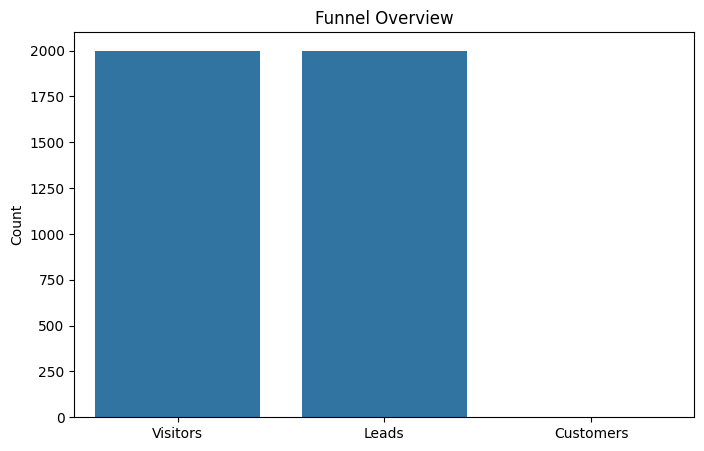

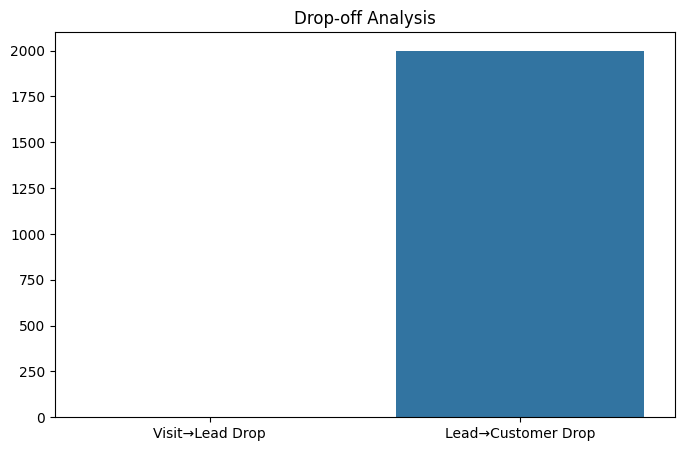


=== INSIGHTS ===
- Leads are not converting: Improve pricing, promotions, or checkout experience
- Focus on top-performing categories for scaling revenue
- Optimize underperforming segments with promotions or bundling


In [17]:
# ----------------------
# 📈 VISUALIZATIONS
# ----------------------

# Funnel Chart
stages = ['Visitors', 'Leads', 'Customers']
values = [total_visitors, total_leads, total_customers]

plt.figure(figsize=(8,5))
sns.barplot(x=stages, y=values)
plt.title("Funnel Overview")
plt.ylabel("Count")
plt.show()

# Drop-off Visualization
drop_values = [drop_visit_lead, drop_lead_customer]

plt.figure(figsize=(8,5))
sns.barplot(x=['Visit→Lead Drop', 'Lead→Customer Drop'], y=drop_values)
plt.title("Drop-off Analysis")
plt.show()

# Category Conversion
if 'product_category' in df.columns:
    plt.figure(figsize=(10,5))
    sns.barplot(data=category_perf, x='product_category', y='lead_to_customer')
    plt.title("Conversion by Product Category")
    plt.xticks(rotation=45)
    plt.show()

# ----------------------
# 💡 INSIGHTS (AUTO-GENERATED)
# ----------------------

print("\n=== INSIGHTS ===")

if visit_to_lead < 0.5:
    print("- High drop-off at Visitor → Lead stage: Improve engagement/offer visibility")

if lead_to_customer < 0.5:
    print("- Leads are not converting: Improve pricing, promotions, or checkout experience")

print("- Focus on top-performing categories for scaling revenue")
print("- Optimize underperforming segments with promotions or bundling")

# <p style="background-color: #1F3A5F; font-family:calibri; color:white; font-size:140%; font-family:Verdana; text-align:center; border-radius:15px 50px;">3.| Save Dataset</p>

In [18]:
df.to_csv("funnel_improved.csv", index=False)